In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
rent = pd.read_csv('rent_raw.csv')

In [42]:
rent

,prezzo,stanze,m2,bagni,piano,description,Riferimento e Data annuncio,contratto,tipologia,superficie,...,certificazione energetica,Emissioni di CO₂,spese aggiuntive,regione,superficie_mq,riferimento,Data_annuncio,categoria,prezzo_mq,giorni_annuncio
0,1800.0,3,60m²,1,"9°, con ascensore","Piazza San Camillo De Lellis, nella signorile ...",ADR9 - 07/03/2023,"Affitto, libero",Appartamento | Intera proprietà | Immobile di ...,60 m² | commerciale 68 m² - Vedi dettaglio,...,NaN,NaN,NaN,NaN,60.0,ADR9,2023-03-07,Appartamento,30.000000,1109
1,450.0,2,55m²,1,"5°, con ascensore","Zona SANTA RITA, precisamente su CORSO AGNELLI...",25481 - 07/03/2023,Affitto,Appartamento | Classe immobile media,55 m²,...,NaN,NaN,NaN,NaN,55.0,25481,2023-03-07,Appartamento,8.181818,1109
2,3200.0,5+,400m²,3+,"2°, con ascensore",Zona pedonale - Si propone in locazione import...,a.118 - 07/03/2023,Affitto,Appartamento | Intera proprietà | Classe immob...,400 m²,...,NaN,NaN,NaN,NaN,400.0,a.118,2023-03-07,Appartamento,8.000000,1109
3,1700.0,5+,200m²,3,1°,Affittasi lussuoso appartamento in villa bifam...,APPARTAMENTO IN VILLA GALLUZZO AFFITTASI - 21/...,"Affitto, 4+4",Villa bifamiliare | Intera proprietà | Classe ...,200 m²,...,NaN,NaN,NaN,NaN,200.0,APPARTAMENTO IN VILLA GALLUZZO AFFITTASI,2022-12-21,Villa bifamiliare,8.500000,1185
4,4000.0,5,160m²,3,Piano terra,La Fortune Real estate srl propone in locazion...,Porto Ercole 4.000 - 06/03/2023,"Affitto, transitorio",Villa a schiera | Intera proprietà | Immobile ...,160 m² - Vedi dettaglio,...,NaN,NaN,NaN,NaN,160.0,Porto Ercole 4.000,2023-03-06,Villa a schiera,25.000000,1110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126262,430.0,1,35m²,1,1° piano,UBICAZIONE E CONTESTOCi troviamo in una delle ...,60783269 - 29/07/2023,Affitto,Appartamento | Intera proprietà | Classe immob...,35 m²,...,NaN,NaN,NaN,veneto,35.0,60783269,2023-07-29,Appartamento,12.285714,965
126263,550.0,3,100m²,1,1°,"Proponiamo in affitto, bifamiliare, parzialmen...",AFF 994 - 29/07/2023,"Affitto, 4+4",Villa bifamiliare | Classe immobile media,100 m² - Vedi dettaglio,...,NaN,NaN,NaN,veneto,100.0,AFF 994,2023-07-29,Villa bifamiliare,5.500000,965
126264,650.0,4,150m²,2,2°,"Nel centro di Ospedaletto Euganeo, proponiamo ...",AFF 995 - 29/07/2023,"Affitto, 4+4",Appartamento | Classe immobile media,150 m² - Vedi dettaglio,...,In attesa di certificazione,NaN,NaN,veneto,150.0,AFF 995,2023-07-29,Appartamento,4.333333,965
126265,5000.0,3,70m²,2,"2 piani: Piano rialzato, 1°","Elegante appartamento su due piani, di nuova c...",EK-105036451 - 29/07/2023,Affitto,Appartamento | Intera proprietà,70 m² | commerciale 75 m² - Vedi dettaglio,...,NaN,NaN,NaN,veneto,70.0,EK,2023-07-29,Appartamento,71.428571,965


In [41]:
# Funzione completa di pulizia del dataset immobiliare
def pulisci_dataset_sale_raw(rent):
    df = rent.copy()

In [8]:
# 1. PREZZO → numerico
if "prezzo" in rent.columns:
    rent["prezzo"] = (
        rent["prezzo"]
        .astype(str)
        .str.replace("€", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.extract(r"(\d+\.?\d*)")[0]
    )

    # Converte in float senza errori
    rent["prezzo"] = pd.to_numeric(rent["prezzo"], errors="coerce")

In [9]:
rent['prezzo']

0         1800.0
1          450.0
2         3200.0
3         1700.0
4         4000.0
           ...  
126262     430.0
126263     550.0
126264     650.0
126265    5000.0
126266     500.0
Name: prezzo, Length: 126267, dtype: float64

In [13]:
   # 2. SUPERFICIE → numerico (m²)
    # -----------------------------
if "superficie" in rent.columns:
    rent["superficie_mq"] = (
        rent["superficie"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

In [14]:
rent['superficie_mq']

0          60.0
1          55.0
2         400.0
3         200.0
4         160.0
          ...  
126262     35.0
126263    100.0
126264    150.0
126265     70.0
126266     60.0
Name: superficie_mq, Length: 126267, dtype: float64

In [15]:
  # 6. RIFERIMENTO + DATA ANNUNCIO
    # -----------------------------
    if "Riferimento e Data annuncio" in df.columns:
        # Estrai riferimento
        rent["riferimento"] = (
            rent["Riferimento e Data annuncio"]
            .astype(str)
            .str.split("-", n=1, expand=True)[0]
            .str.strip()
        )

IndentationError: unexpected indent (1851045353.py, line 3)

In [19]:
  # 6. RIFERIMENTO + DATA ANNUNCIO
    # -----------------------------
if "Riferimento e Data annuncio" in rent.columns:
    col = rent["Riferimento e Data annuncio"].astype(str)

    # Separa solo se c'è il trattino
    rent["riferimento"] = col.apply(
        lambda x: x.split("-", 1)[0].strip() if "-" in x else np.nan
    )

rent["Data_annuncio"] = col.str.extract(r"(\d{2}/\d{2}/\d{4})")[0]
rent["Data_annuncio"] = pd.to_datetime(
    rent["Data_annuncio"], format="%d/%m/%Y", errors="coerce"
)


In [20]:
rent['Data_annuncio']

0        2023-03-07
1        2023-03-07
2        2023-03-07
3        2022-12-21
4        2023-03-06
            ...    
126262   2023-07-29
126263   2023-07-29
126264   2023-07-29
126265   2023-07-29
126266   2023-07-29
Name: Data_annuncio, Length: 126267, dtype: datetime64[ns]

In [23]:
    # 7. TIPOLOGIA → estrai categoria principale
    # -----------------------------
    if "tipologia" in rent.columns:
        rent["categoria"] = (
            rent["tipologia"]
            .astype(str)
            .str.split("|", expand=True)[0]
            .str.strip()
        )

    # -----------------------------
    # 8. NORMALIZZAZIONE TESTO
    # -----------------------------
    colonne_testo = ["description", "tipologia", "piano"]
    for col in colonne_testo:
        if col in rent.columns:
            rent[col] = rent[col].astype(str).str.strip()



In [24]:
rent['categoria']

0              Appartamento
1              Appartamento
2              Appartamento
3         Villa bifamiliare
4           Villa a schiera
                ...        
126262         Appartamento
126263    Villa bifamiliare
126264         Appartamento
126265         Appartamento
126266         Appartamento
Name: categoria, Length: 126267, dtype: object

In [26]:
# prezzo_mq
rent["prezzo_mq"] = rent["prezzo"] / rent["superficie_mq"]


In [27]:
rent["prezzo_mq"]

0         30.000000
1          8.181818
2          8.000000
3          8.500000
4         25.000000
            ...    
126262    12.285714
126263     5.500000
126264     4.333333
126265    71.428571
126266     8.333333
Name: prezzo_mq, Length: 126267, dtype: float64

In [28]:
#totale giorni di annunci
rent["giorni_annuncio"] = (pd.Timestamp.today() - rent["Data_annuncio"]).dt.days



In [29]:
rent["giorni_annuncio"]

0         1109
1         1109
2         1109
3         1185
4         1110
          ... 
126262     965
126263     965
126264     965
126265     965
126266     965
Name: giorni_annuncio, Length: 126267, dtype: int64

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribuzione_prezzi(rent):
    plt.figure(figsize=(10,5))
    sns.histplot(rent["prezzo"], kde=True, bins=40, color="royalblue")
    plt.title("Distribuzione dei prezzi")
    plt.xlabel("Prezzo (€)")
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.show()

In [32]:
def plot_boxplot_tipologia(rent, colonna_valore="prezzo"):
    plt.figure(figsize=(12,6))
    sns.boxplot(
        data=rent,
        x="categoria",
        y=colonna_valore,
        palette="Set2"
    )
    plt.title(f"Distribuzione di {colonna_valore} per tipologia")
    plt.xlabel("Tipologia")
    plt.ylabel(colonna_valore)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [33]:
def plot_distribuzione_prezzi(rent):
    plt.figure(figsize=(10,5))

    # Filtra valori validi
    prezzi = pd.to_numeric(rent["prezzo"], errors="coerce").dropna()

    sns.histplot(prezzi, kde=True, bins=40, color="royalblue")
    plt.title("Distribuzione dei prezzi")
    plt.xlabel("Prezzo (€)")
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.show()


In [75]:
def plot_heatmap(rent):
    plt.figure(figsize=(12,8))
    corr = rent.select_dtypes(include=["float64", "int64"]).corr()
    sns.heatmap(
        corr,
        annot=True,
        cmap="viridis",
        linewidths=.5,
        fmt=".2f"
    )
    plt.title("Heatmap delle correlazioni numeriche")
    plt.tight_layout()
    plt.show()


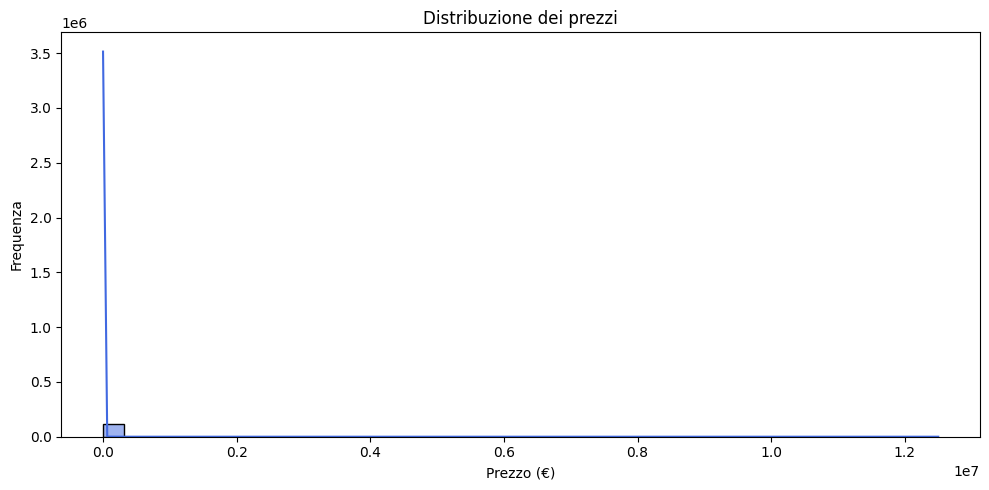

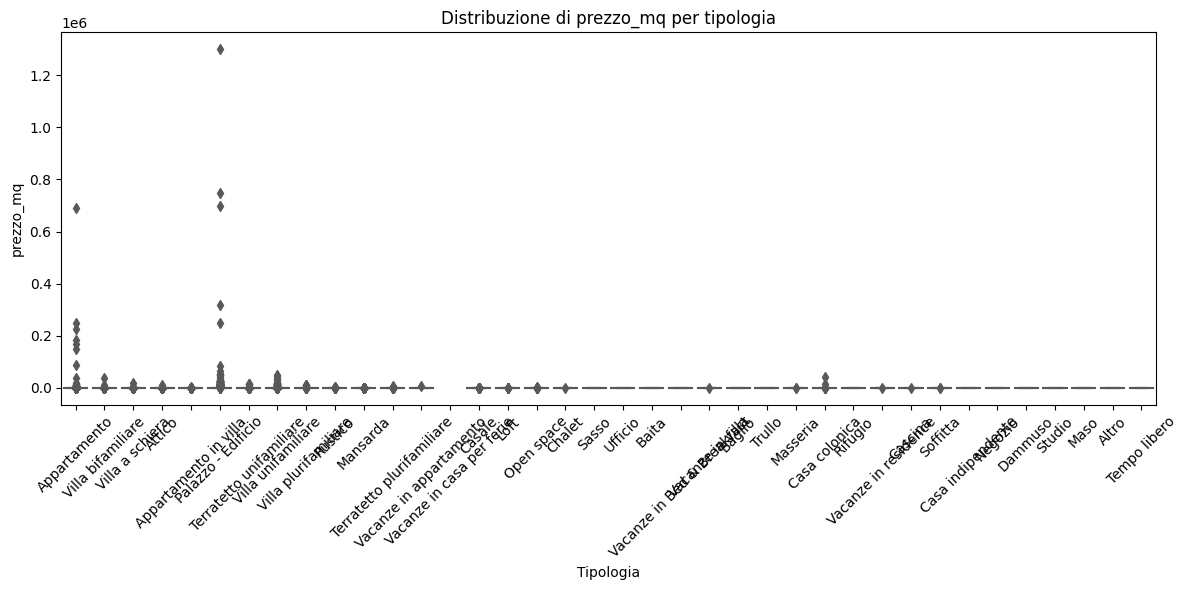

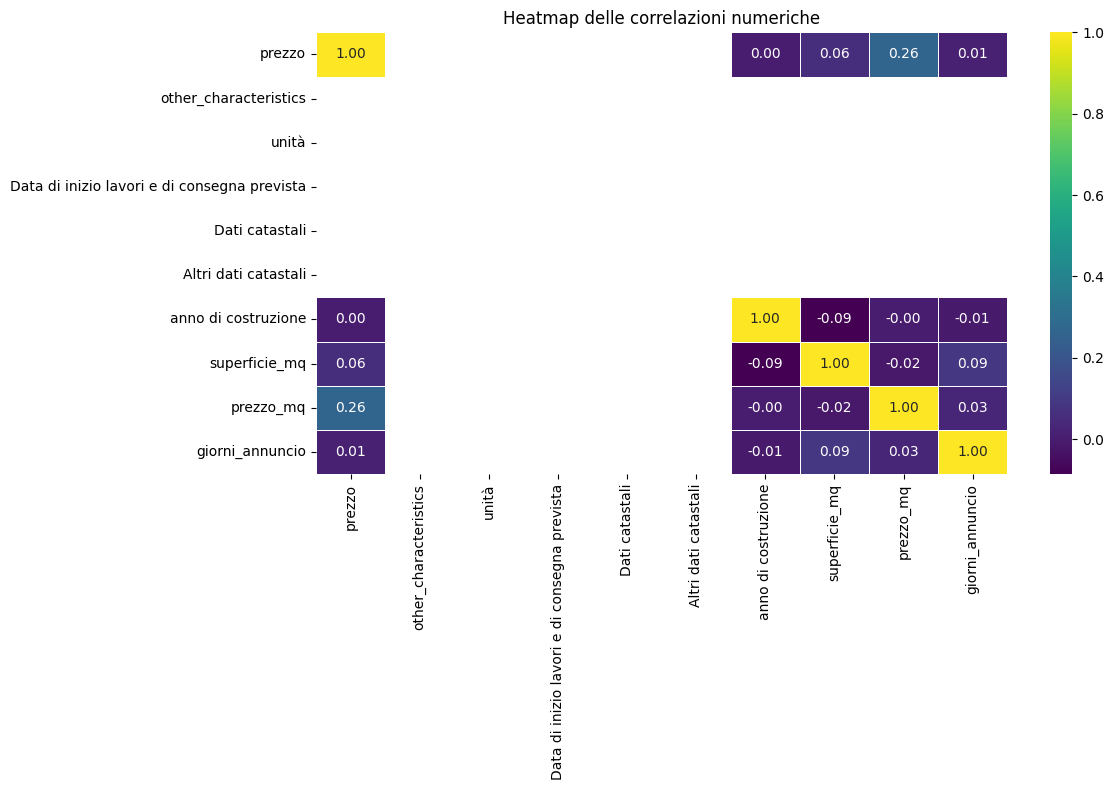

In [76]:
plot_distribuzione_prezzi(rent)
plot_boxplot_tipologia(rent, "prezzo_mq")
plot_heatmap(rent)

In [38]:
def plot_prezzi_per_zona(rent, col_zona="regione"):
    plt.figure(figsize=(12,6))
    rent_group = rent.groupby(col_zona)["prezzo"].mean().sort_values()
    sns.barplot(x=rent_group.index, y=rent_group.values, palette="viridis")
    plt.title("Prezzo mediano per zona")
    plt.xlabel("regione")
    plt.ylabel("Prezzo mediano (€)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

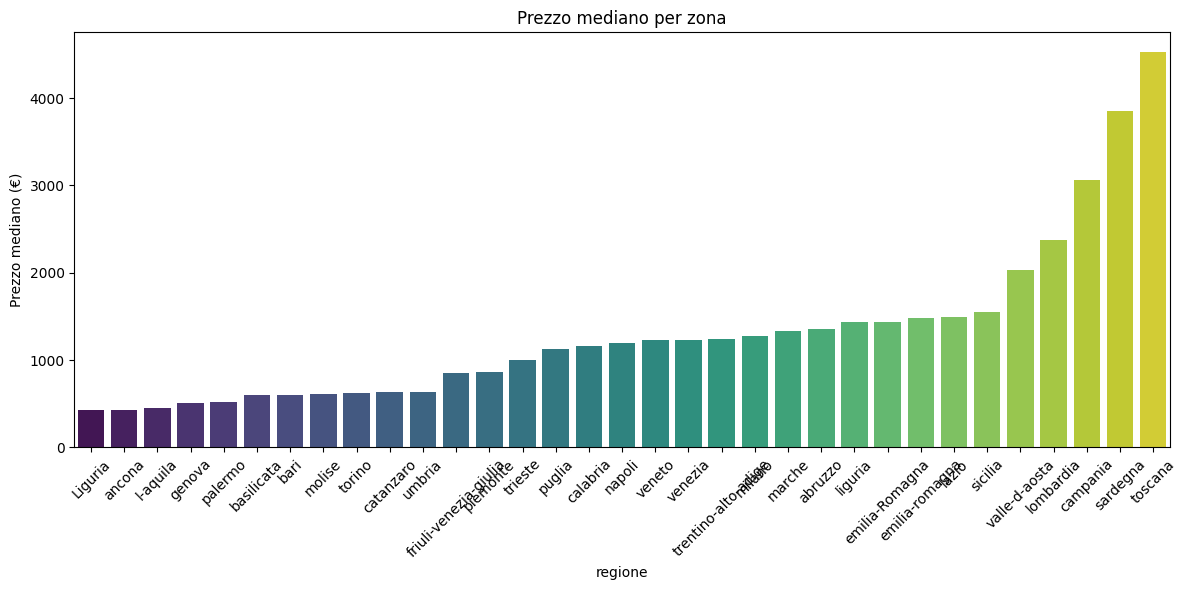

In [39]:
plot_prezzi_per_zona(rent, col_zona="regione")

In [ ]:
#elimino alcune colonne che non servono
rent_clean = rent.drop(columns=["spese aggiuntive","Emissioni di CO₂","certificazione energetica",
                                "Prestazione energetica del fabbricato","Indice prest. energetica rinnovabile,	Efficienza energetica,Climatizzatore,riscaldamento,stato,contratto])a

In [44]:
rent.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126267 entries, 0 to 126266
Data columns (total 44 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   prezzo                                        120537 non-null  float64       
 1   stanze                                        125956 non-null  object        
 2   m2                                            124827 non-null  object        
 3   bagni                                         122597 non-null  object        
 4   piano                                         126267 non-null  object        
 5   description                                   126267 non-null  object        
 6   Riferimento e Data annuncio                   126267 non-null  object        
 7   contratto                                     126267 non-null  object        
 8   tipologia                                     126267 n

In [45]:
rent_clean = rent.drop(columns=["bagni","piano", "contratto","locali", "totale piani edificio",  
"Posti Auto","disponibilità","other_characteristics","quartiere","href" ,"via"  ,"unità", "Data di inizio lavori e di consegna prevista",
"Uso edificio attuale","Dati catastali","Altri dati catastali","altre caratteristiche","spese condominio",
"cauzione","anno di costruzione","stato","riscaldamento","Climatizzatore","Efficienza energetica",
"Indice prest. energetica rinnovabile","Prestazione energetica del fabbricato","certificazione energetica",
"Emissioni di CO₂","spese aggiuntive","riferimento"])

In [46]:
rent_clean

,prezzo,stanze,m2,description,Riferimento e Data annuncio,tipologia,superficie,citta,regione,superficie_mq,Data_annuncio,categoria,prezzo_mq,giorni_annuncio
0,1800.0,3,60m²,"Piazza San Camillo De Lellis, nella signorile ...",ADR9 - 07/03/2023,Appartamento | Intera proprietà | Immobile di ...,60 m² | commerciale 68 m² - Vedi dettaglio,Milano,NaN,60.0,2023-03-07,Appartamento,30.000000,1109
1,450.0,2,55m²,"Zona SANTA RITA, precisamente su CORSO AGNELLI...",25481 - 07/03/2023,Appartamento | Classe immobile media,55 m²,Torino,NaN,55.0,2023-03-07,Appartamento,8.181818,1109
2,3200.0,5+,400m²,Zona pedonale - Si propone in locazione import...,a.118 - 07/03/2023,Appartamento | Intera proprietà | Classe immob...,400 m²,Padova,NaN,400.0,2023-03-07,Appartamento,8.000000,1109
3,1700.0,5+,200m²,Affittasi lussuoso appartamento in villa bifam...,APPARTAMENTO IN VILLA GALLUZZO AFFITTASI - 21/...,Villa bifamiliare | Intera proprietà | Classe ...,200 m²,Firenze,NaN,200.0,2022-12-21,Villa bifamiliare,8.500000,1185
4,4000.0,5,160m²,La Fortune Real estate srl propone in locazion...,Porto Ercole 4.000 - 06/03/2023,Villa a schiera | Intera proprietà | Immobile ...,160 m² - Vedi dettaglio,Monte Argentario,NaN,160.0,2023-03-06,Villa a schiera,25.000000,1110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126262,430.0,1,35m²,UBICAZIONE E CONTESTOCi troviamo in una delle ...,60783269 - 29/07/2023,Appartamento | Intera proprietà | Classe immob...,35 m²,Vicenza,veneto,35.0,2023-07-29,Appartamento,12.285714,965
126263,550.0,3,100m²,"Proponiamo in affitto, bifamiliare, parzialmen...",AFF 994 - 29/07/2023,Villa bifamiliare | Classe immobile media,100 m² - Vedi dettaglio,Montagnana,veneto,100.0,2023-07-29,Villa bifamiliare,5.500000,965
126264,650.0,4,150m²,"Nel centro di Ospedaletto Euganeo, proponiamo ...",AFF 995 - 29/07/2023,Appartamento | Classe immobile media,150 m² - Vedi dettaglio,Ospedaletto Euganeo,veneto,150.0,2023-07-29,Appartamento,4.333333,965
126265,5000.0,3,70m²,"Elegante appartamento su due piani, di nuova c...",EK-105036451 - 29/07/2023,Appartamento | Intera proprietà,70 m² | commerciale 75 m² - Vedi dettaglio,Roana,veneto,70.0,2023-07-29,Appartamento,71.428571,965


In [48]:
rent_clean

,prezzo,stanze,m2,bagni,piano,contratto,tipologia,superficie,locali,totale piani edificio,...,certificazione energetica,Emissioni di CO₂,spese aggiuntive,regione,superficie_mq,riferimento,Data_annuncio,categoria,prezzo_mq,giorni_annuncio
0,1800.0,3,60m²,1,"9°, con ascensore","Affitto, libero",Appartamento | Intera proprietà | Immobile di ...,60 m² | commerciale 68 m² - Vedi dettaglio,"3 (2 camere da letto, 1 altro), 1 bagno, cucin...",10 piani,...,NaN,NaN,NaN,NaN,60.0,ADR9,2023-03-07,Appartamento,30.000000,1109
1,450.0,2,55m²,1,"5°, con ascensore",Affitto,Appartamento | Classe immobile media,55 m²,"2 (1 camera da letto, 1 altro), 1 bagno, cucin...",5 piani,...,NaN,NaN,NaN,NaN,55.0,25481,2023-03-07,Appartamento,8.181818,1109
2,3200.0,5+,400m²,3+,"2°, con ascensore",Affitto,Appartamento | Intera proprietà | Classe immob...,400 m²,"5+ (5 camere da letto, 3 altri), 3+ bagni, cuc...",3 piani,...,NaN,NaN,NaN,NaN,400.0,a.118,2023-03-07,Appartamento,8.000000,1109
3,1700.0,5+,200m²,3,1°,"Affitto, 4+4",Villa bifamiliare | Intera proprietà | Classe ...,200 m²,"5+ (4 camere da letto, 4 altri), 3 bagni, cuci...",1 piano,...,NaN,NaN,NaN,NaN,200.0,APPARTAMENTO IN VILLA GALLUZZO AFFITTASI,2022-12-21,Villa bifamiliare,8.500000,1185
4,4000.0,5,160m²,3,Piano terra,"Affitto, transitorio",Villa a schiera | Intera proprietà | Immobile ...,160 m² - Vedi dettaglio,"5 (4 camere da letto, 1 altro), 3 bagni, cucin...",2 piani,...,NaN,NaN,NaN,NaN,160.0,Porto Ercole 4.000,2023-03-06,Villa a schiera,25.000000,1110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126262,430.0,1,35m²,1,1° piano,Affitto,Appartamento | Intera proprietà | Classe immob...,35 m²,"1 camera da letto, 1 bagno, cucina semi abitabile",3 piani,...,NaN,NaN,NaN,veneto,35.0,60783269,2023-07-29,Appartamento,12.285714,965
126263,550.0,3,100m²,1,1°,"Affitto, 4+4",Villa bifamiliare | Classe immobile media,100 m² - Vedi dettaglio,"3 (2 camere da letto, 1 altro), 1 bagno, cucin...",1 piano,...,NaN,NaN,NaN,veneto,100.0,AFF 994,2023-07-29,Villa bifamiliare,5.500000,965
126264,650.0,4,150m²,2,2°,"Affitto, 4+4",Appartamento | Classe immobile media,150 m² - Vedi dettaglio,"4 (3 camere da letto, 1 altro), 2 bagni, cucin...",2 piani,...,In attesa di certificazione,NaN,NaN,veneto,150.0,AFF 995,2023-07-29,Appartamento,4.333333,965
126265,5000.0,3,70m²,2,"2 piani: Piano rialzato, 1°",Affitto,Appartamento | Intera proprietà,70 m² | commerciale 75 m² - Vedi dettaglio,"3 (2 camere da letto, 1 altro), 2 bagni",2 piani,...,NaN,NaN,NaN,veneto,70.0,EK,2023-07-29,Appartamento,71.428571,965


In [52]:
#conteggio per singola categoria
rent_clean['categoria'].value_counts()

Appartamento                  112397
Villa unifamiliare              3492
Attico                          2082
Mansarda                        1370
Terratetto unifamiliare         1201
Villa a schiera                 1182
Villa bifamiliare               1008
Palazzo - Edificio               903
Appartamento in villa            713
Loft                             449
Villa plurifamiliare             319
Terratetto plurifamiliare        290
Open space                       228
Casale                           185
Rustico                          163
Casa colonica                     88
Vacanze in appartamento           33
Chalet                            33
Trullo                            33
Baita                             21
Masseria                          17
Vacanze in villa                  14
Soffitta                           9
Cascina                            9
Vacanze in residence               7
Vacanze in casa per ferie          4
Maso                               3
A

In [59]:
rent_clean["prezzo"].mean()

1847.454375005185

In [60]:
rent_clean["prezzo_mq"].mean()

86.98097502684163

In [61]:
rent_clean["superficie_mq"].mean()

82.79617712035348

In [62]:
rent_clean["giorni_annuncio"].mean

<bound method NDFrame._add_numeric_operations.<locals>.mean of 0         1109
1         1109
2         1109
3         1185
4         1110
          ... 
126262     965
126263     965
126264     965
126265     965
126266     965
Name: giorni_annuncio, Length: 126267, dtype: int64>

In [63]:
rent_clean.shape[0]

126267

In [64]:
#prezzo medio per categoria
rent_clean.groupby("categoria")["prezzo_mq"].mean()

categoria
Altro                            8.262626
Appartamento                    36.927869
Appartamento in villa           23.951608
Attico                          25.618392
Baglio                          13.750000
Baita                           15.659359
Casa colonica                  668.555899
Casa indipendente                7.000000
Casale                          32.110218
Cascina                          9.815297
Chalet                          32.430507
Dammuso                         12.348485
Loft                            17.075700
Mansarda                        12.932125
Maso                            20.084034
Masseria                         7.666772
Negozio                         16.129032
Open space                      34.508296
Palazzo - Edificio            7666.840224
Rifugio                         12.500000
Rustico                         52.817025
Sasso                           16.636364
Soffitta                        24.347799
Studio                  

In [65]:
rent_clean.groupby("regione")["prezzo_mq"]


In [66]:
def plot_prezzo_per_regione(rent):
    df_reg = (
        rent_clean.groupby("regione")["prezzo_mq"]
        .median()
        .sort_values()
    )

    plt.figure(figsize=(12,6))
    sns.barplot(
        x=df_reg.index,
        y=df_reg.values,
        palette="viridis"
    )
    plt.title("Prezzo mediano al m² per regione")
    plt.xlabel("Regione")
    plt.ylabel("Prezzo mediano al m² (€)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

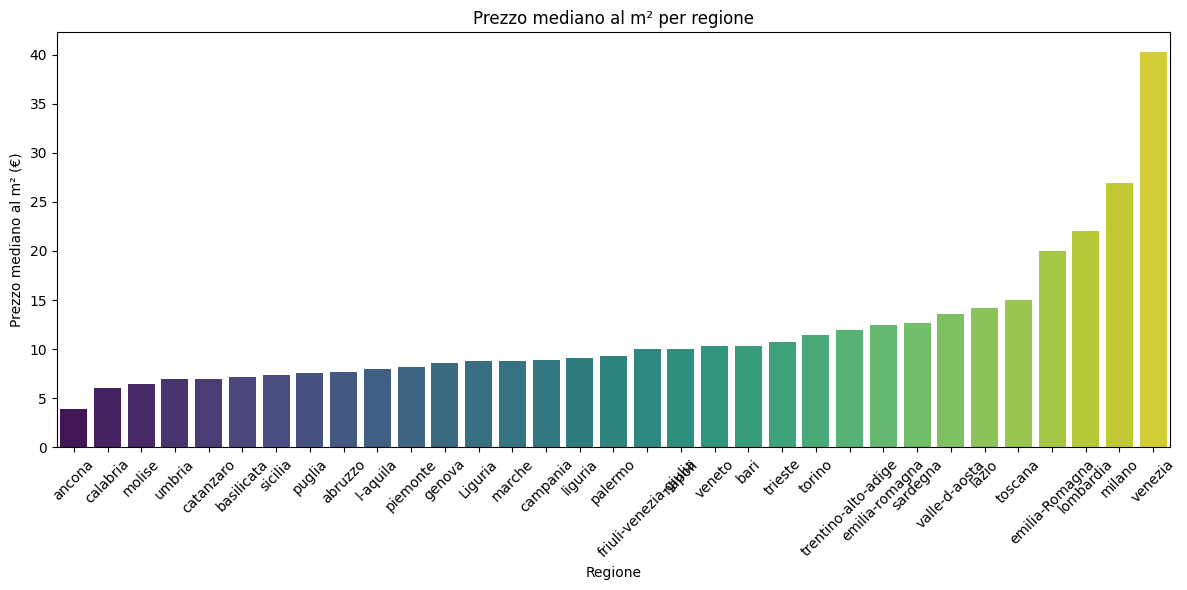

In [67]:
plot_prezzo_per_regione(rent_clean)

c:\Users\mrand\anaconda3\envs\rstudio\lib\site-packages\seaborn\algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
c:\Users\mrand\anaconda3\envs\rstudio\lib\site-packages\numpy\lib\nanfunctions.py:1376: RuntimeWarning: All-NaN slice encountered
  overwrite_input=overwrite_input, interpolation=interpolation


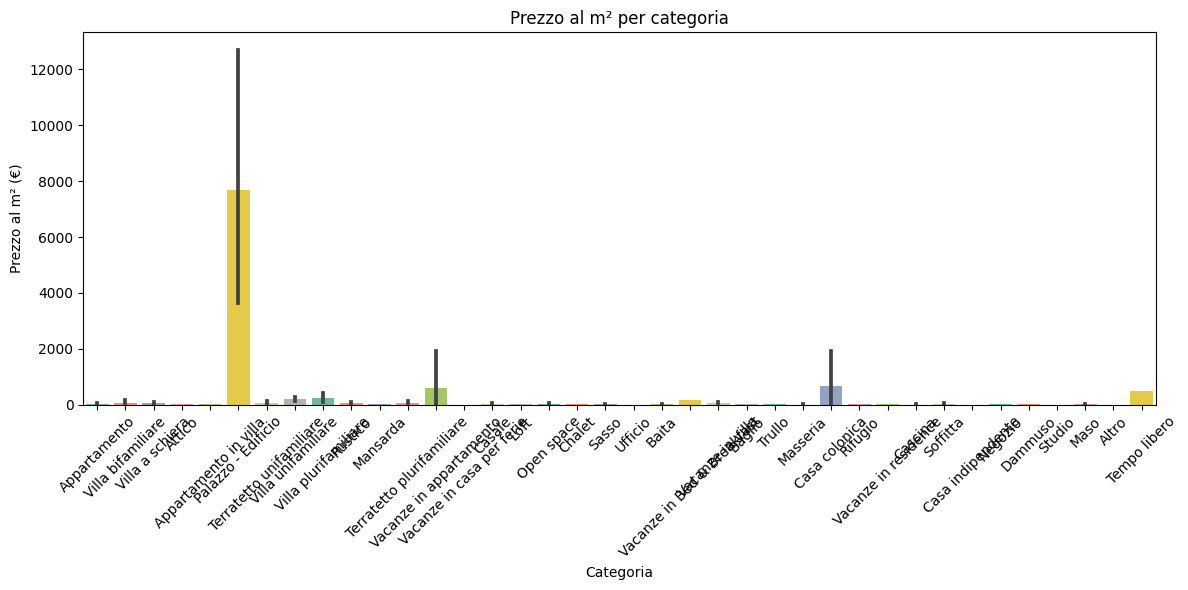

In [69]:
 if "categoria" in rent_clean.columns:
        plt.figure(figsize=(12, 6))
        sns.barplot(
            data=rent,
            x="categoria",
            y="prezzo_mq",
            palette="Set2"
        )
        plt.title("Prezzo al m² per categoria")
        plt.xlabel("Categoria")
        plt.ylabel("Prezzo al m² (€)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()



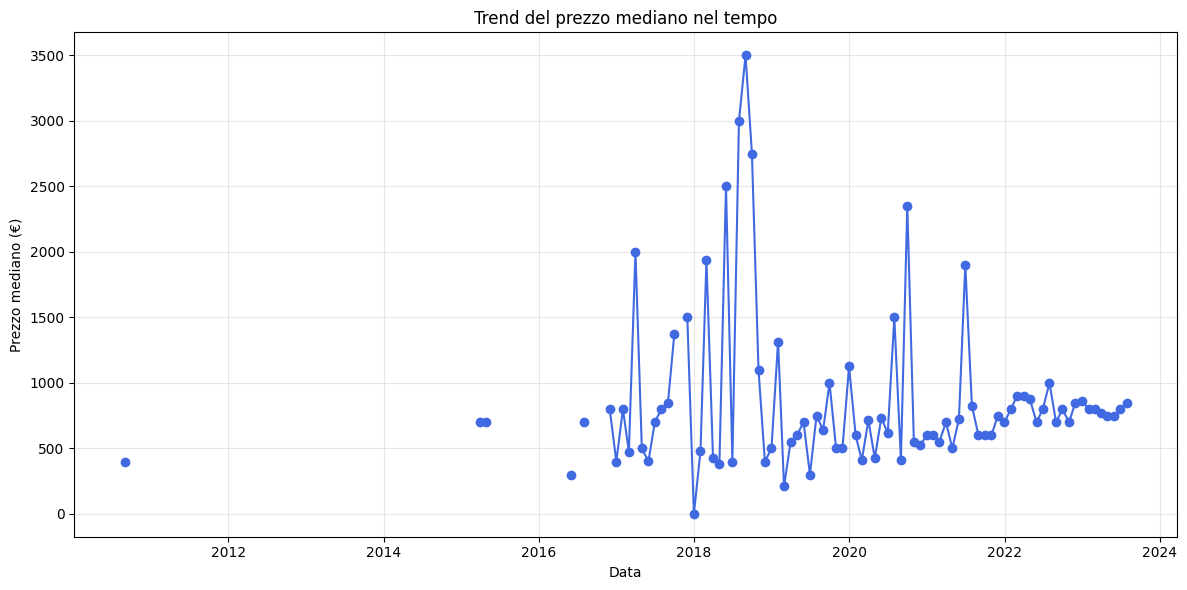

In [70]:
if "Data_annuncio" in rent_clean.columns:
        df_temp = (
            rent.dropna(subset=["Data_annuncio"])
            .set_index("Data_annuncio")
            .resample("M")["prezzo"]
            .median()
        )

        plt.figure(figsize=(12, 6))
        plt.plot(df_temp.index, df_temp.values, marker="o", color="royalblue")
        plt.title("Trend del prezzo mediano nel tempo")
        plt.xlabel("Data")
        plt.ylabel("Prezzo mediano (€)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

